# 607 - Marsh crossing

In [62]:
# Set packages
import pandas as pd
import numpy as np
import plotnine as p9
from scipy.optimize import minimize

In [89]:
# Set constants
ONE_OVER_TEN = 1/10
ONE_OVER_NINE = 1/9
ONE_OVER_EIGHT = 1/8
ONE_OVER_SEVEN = 1/7
ONE_OVER_SIX = 1/6
ONE_OVER_FIVE = 1/5
D1 = (100/np.sqrt(2)-50)/2    # Distance from A to marsh region in X direction
D1_square = D1**2    # Distance from A to marsh region in X direction, squared
Y = 100/np.sqrt(2)   # Distance from A to B in y direction

In [90]:
# Define functions

# Define what to optimize
def f(x):
    out = (np.sqrt(x[0]**2+100)*ONE_OVER_NINE + 
           np.sqrt(x[1]**2+100)*ONE_OVER_EIGHT + 
           np.sqrt(x[2]**2+100)*ONE_OVER_SEVEN + 
           np.sqrt(x[3]**2+100)*ONE_OVER_SIX + 
           np.sqrt(x[4]**2+100)*ONE_OVER_FIVE + 
           2*np.sqrt(D1_square + (np.abs(Y-x.sum())/2)**2)*ONE_OVER_TEN
          )
    return out


# # Define optimization function
# def optimize_function(n_points)

In [100]:
# Run optimization
# x_start = np.array([10, 9, 8, 7, 6])
x_start = np.array([.5, .5, .5, .5, .5])
temp = minimize(f, x_start, method='Nelder-Mead', options={'fatol': 1e-11, 'maxiter':1000})

f_min = f(temp['x'])
y_opt = temp['x']
temp
print('Best solution:', round(f_min,10))

Best solution: 13.1265108586


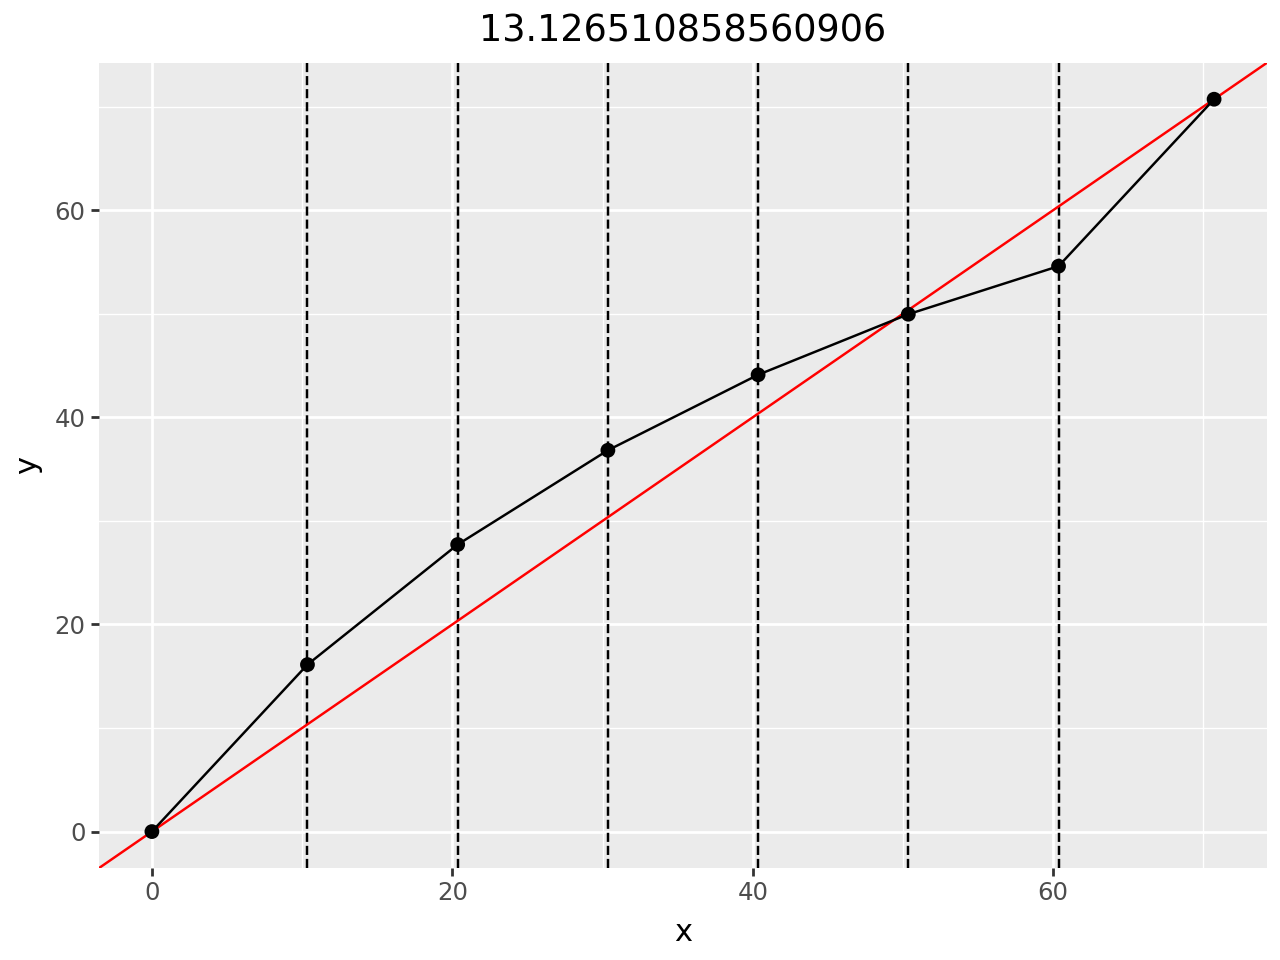

In [96]:
# Plot final curve
start_y = (Y-y_opt.sum())/2
np.concatenate(([0], [start_y], y_opt.cumsum() + start_y, [Y]))
# y = y_opt.cumsum() + (Y-y_opt.sum())/2
x = [D1, D1+10, D1+20, D1+30, D1+40, D1+50]
plot_data = pd.DataFrame({'x': np.concatenate(([0], x, [Y])), 
                          'y': np.concatenate(([0], [start_y], y_opt.cumsum() + start_y, [Y]))})
p = (p9.ggplot(plot_data) + 
     p9.aes(x='x', y='y') + 
     p9.geom_vline(xintercept=x, color='black', linetype='dashed') +
     p9.geom_abline(intercept=0, slope=1, color='red') +
     p9.geom_line() + 
     p9.geom_point(size=2) + 
     p9.ggtitle(f_min)
    )
p.show()